
# EOD PCA-SVM Momentum Grid Search

Vectorized grid search over `pca_svm_momentum_signal` parameters for the
end-of-day `USD-SOFR-1D-Q12STIRT` / `IMM_4xIMM_5` strategy.

The notebook mirrors the workflow in `svr_momentum_grid_search.ipynb`:
1. load one contract history
2. sweep a parameter grid with a fast vectorized PnL approximation
3. inspect top combinations and heatmaps
4. run the best combination through the query-driven backtest

`trade_direction` controls rate-direction semantics for both the vectorized
sweep and the query backtest:
- `+1.0` => receiver-long
- `-1.0` => payer-long


In [96]:

%load_ext autoreload
%autoreload 2

import datetime
import itertools
import sys
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pytz
import seaborn as sns

sys.path.append('../../')

from BT.signals import pca_svm_momentum_signal, run_technical_indicator_query_backtest
from MDP.IRSwaps.IRSwapsMDP import IRSwapsMDP
from Query.IRSwaps.IRSwapQuery import IRSwapQuery
from Query.IRSwaps.IRSwapValue import IRSwapValue
from Query.Unified.UnifiedQuery import UnifiedQuery
from Query.Unified.registry import UnifiedValue
from TB.IRSwapsTB import IRSwapsTB
from TB.TimeseriesBuilder import TimeseriesBuilder

NYC = pytz.timezone('America/New_York')


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [97]:

# -- Load EOD data ------------------------------------------------------
curve_mdp = IRSwapsMDP(source='BARCHART_STIRF-RL')
ts_builder = TimeseriesBuilder()

trade_bpv = 25_00.0
transaction_cost_bps = 0.25
trade_direction = 1.0  # +1.0 = receiver-long, -1.0 = payer-long

start = NYC.localize(datetime.datetime(2024, 3, 27, 18, 0))
end = NYC.localize(datetime.datetime(2026, 3, 27, 17, 0))

tenor = "IMM_8xIMM_9"

q = UnifiedQuery(
    curve='USD-SOFR-1D-Q12STIRT',
    tenor=tenor,
    value=UnifiedValue.IRS_RATE,
)

eod_df = ts_builder.get_timeseries(
    start=start,
    end=end,
    queries=[q],
    freq='nyc_eod',
    n_jobs=12,
    routers={
        'IRS': IRSwapsTB(curve_mdp, show_tqdm=False),
    },
    ignore_cache_miss=True,
)

rate_series = pd.to_numeric(eod_df.iloc[:, 0], errors='coerce').dropna()
rate_series.name = tenor

print(f'Loaded {len(rate_series)} EOD bars from {rate_series.index[0]} to {rate_series.index[-1]}')
rate_series.tail()


WARNING	Task(Task-2) Caching.computed_timeseries_store:computed_timeseries_store.py:_open_duckdb_graceful()- DuckDB unavailable (file locked), falling back to parquet-only: C:\Users\chris\clee\ARBS\data\ts\computed_ts.duckdb


Loaded 498 EOD bars from 2024-03-28 17:00:00-04:00 to 2026-03-27 17:00:00-04:00


Date
2026-03-23 17:00:00-04:00    3.440976
2026-03-24 17:00:00-04:00    3.465628
2026-03-25 17:00:00-04:00    3.448239
2026-03-26 17:00:00-04:00    3.547878
2026-03-27 17:00:00-04:00    3.517129
Name: IMM_8xIMM_9, dtype: float64

In [98]:
# -- Vectorized PnL helper ----------------------------------------------
def vectorized_metrics(
    signal_result,
    rate_series,
    *,
    trade_bpv=100_000.0,
    cost_bps=0.25,
    trade_direction=1.0,
):
    position = signal_result.execution_position.fillna(0.0).astype(float)
    signed_position = position * float(trade_direction)
    delta = rate_series.diff().fillna(0.0)
    gross_pnl = -signed_position * delta * float(trade_bpv) * 100.0

    trade_sides = signed_position.diff().abs().fillna(0.0)
    if len(trade_sides):
        trade_sides.iloc[0] = abs(float(signed_position.iloc[0]))
    costs = trade_sides * float(cost_bps) * float(trade_bpv)
    net_pnl = gross_pnl - costs

    cumulative = net_pnl.cumsum()
    total_pnl = float(cumulative.iloc[-1]) if len(cumulative) else 0.0
    n_trades = float(trade_sides.sum())
    std = float(net_pnl.std())
    sharpe = float(net_pnl.mean() / std * np.sqrt(252.0)) if std > 0.0 else 0.0
    drawdown = cumulative - cumulative.cummax()
    max_dd = float(drawdown.min()) if len(drawdown) else 0.0
    nonzero = net_pnl[net_pnl != 0.0]
    win_rate = float((nonzero > 0).mean()) if len(nonzero) else 0.0
    exposure_bars = int(position.ne(0.0).sum())

    return {
        'total_pnl': total_pnl,
        'sharpe': sharpe,
        'max_drawdown': max_dd,
        'n_trades': n_trades,
        'win_rate': win_rate,
        'exposure_bars': exposure_bars,
        'cumulative': cumulative,
    }


In [99]:

# -- Define grid --------------------------------------------------------
WINDOW_PRESETS = {
    'matlab_daily': ([7, 14, 20], [50, 75, 100]),
    'fast_daily': ([5, 10, 14], [30, 50, 75]),
    'slow_daily': ([10, 20, 30], [75, 100, 150]),
}

RETRAIN_PRESETS = {
    'single_split': None,
    '20_bar': 20,
    '60_bar': 60,
}

GRID = {
    'svm_c': [0.02, 0.1, 1.0, 10.0],
    'svm_gamma': [0.01, 0.1, 1.0],
    'z_threshold': [1.25, 1.75, 2.25],
    'retrain_label': list(RETRAIN_PRESETS.keys()),
    'windows': list(WINDOW_PRESETS.keys()),
}

n_combos = 1
for values in GRID.values():
    n_combos *= len(values)
print(f'Grid has {n_combos} parameter combinations')


Grid has 324 parameter combinations


In [100]:

# -- Run grid search ----------------------------------------------------
results = []
keys = list(GRID.keys())
combos = list(itertools.product(*GRID.values()))

t_start = time.perf_counter()
for i, combo in enumerate(combos, start=1):
    params = dict(zip(keys, combo))
    window_key = params['windows']
    short_spans, long_spans = WINDOW_PRESETS[window_key]
    retrain_every = RETRAIN_PRESETS[params['retrain_label']]

    try:
        sig = pca_svm_momentum_signal(
            rate_series,
            ewma_short_spans=short_spans,
            ewma_long_spans=long_spans,
            n_components=2,
            svm_c=params['svm_c'],
            svm_gamma=params['svm_gamma'],
            label_window=10,
            z_threshold=params['z_threshold'],
            train_fraction=0.7,
            retrain_every=retrain_every,
        )
        metrics = vectorized_metrics(
            sig,
            rate_series,
            trade_bpv=trade_bpv,
            cost_bps=transaction_cost_bps,
            trade_direction=trade_direction,
        )
        row = {
            'windows': window_key,
            'ewma_short_spans': str(short_spans),
            'ewma_long_spans': str(long_spans),
            'retrain_label': params['retrain_label'],
            'retrain_every': retrain_every,
            'svm_c': params['svm_c'],
            'svm_gamma': params['svm_gamma'],
            'z_threshold': params['z_threshold'],
            'total_pnl': metrics['total_pnl'],
            'sharpe': metrics['sharpe'],
            'max_drawdown': metrics['max_drawdown'],
            'n_trades': metrics['n_trades'],
            'win_rate': metrics['win_rate'],
            'exposure_bars': metrics['exposure_bars'],
            'error': None,
        }
    except Exception as exc:
        row = {
            'windows': window_key,
            'ewma_short_spans': str(short_spans),
            'ewma_long_spans': str(long_spans),
            'retrain_label': params['retrain_label'],
            'retrain_every': retrain_every,
            'svm_c': params['svm_c'],
            'svm_gamma': params['svm_gamma'],
            'z_threshold': params['z_threshold'],
            'total_pnl': np.nan,
            'sharpe': np.nan,
            'max_drawdown': np.nan,
            'n_trades': np.nan,
            'win_rate': np.nan,
            'exposure_bars': np.nan,
            'error': str(exc),
        }

    results.append(row)

    if i % 25 == 0 or i == len(combos):
        elapsed = time.perf_counter() - t_start
        rate = i / elapsed if elapsed > 0 else 0.0
        eta = (len(combos) - i) / rate if rate > 0 else 0.0
        print(f'  [{i}/{len(combos)}] {elapsed:.0f}s elapsed, {rate:.2f} combos/s, ETA {eta:.0f}s')

grid_df = pd.DataFrame(results)
print(f'Completed {len(grid_df)} combinations in {time.perf_counter() - t_start:.1f}s')
grid_df.head()


  [25/324] 1s elapsed, 46.77 combos/s, ETA 6s
  [50/324] 1s elapsed, 49.11 combos/s, ETA 6s
  [75/324] 1s elapsed, 50.59 combos/s, ETA 5s
  [100/324] 2s elapsed, 50.02 combos/s, ETA 4s
  [125/324] 3s elapsed, 48.82 combos/s, ETA 4s
  [150/324] 3s elapsed, 49.00 combos/s, ETA 4s
  [175/324] 4s elapsed, 49.09 combos/s, ETA 3s
  [200/324] 4s elapsed, 50.12 combos/s, ETA 2s
  [225/324] 4s elapsed, 50.55 combos/s, ETA 2s
  [250/324] 5s elapsed, 51.03 combos/s, ETA 1s
  [275/324] 5s elapsed, 51.70 combos/s, ETA 1s
  [300/324] 6s elapsed, 52.14 combos/s, ETA 0s
  [324/324] 6s elapsed, 51.83 combos/s, ETA 0s
Completed 324 combinations in 6.3s


,windows,ewma_short_spans,ewma_long_spans,retrain_label,retrain_every,svm_c,svm_gamma,z_threshold,total_pnl,sharpe,max_drawdown,n_trades,win_rate,exposure_bars,error
0,matlab_daily,"[7, 14, 20]","[50, 75, 100]",single_split,NaN,0.02,0.01,1.25,108347.705142,0.614676,-114889.795368,1.0,0.495798,119,None
1,fast_daily,"[5, 10, 14]","[30, 50, 75]",single_split,NaN,0.02,0.01,1.25,108679.541593,0.599922,-114889.795368,1.0,0.496063,127,None
2,slow_daily,"[10, 20, 30]","[75, 100, 150]",single_split,NaN,0.02,0.01,1.25,118669.982137,0.717430,-114889.795368,1.0,0.509615,104,None
3,matlab_daily,"[7, 14, 20]","[50, 75, 100]",20_bar,20.0,0.02,0.01,1.25,222726.792758,1.265921,-52201.068906,5.0,0.512605,119,None
4,fast_daily,"[5, 10, 14]","[30, 50, 75]",20_bar,20.0,0.02,0.01,1.25,92679.515758,0.511927,-114889.795368,3.0,0.503937,127,None


In [101]:

# -- Top results by Sharpe ----------------------------------------------
top = grid_df.dropna(subset=['sharpe']).sort_values('sharpe', ascending=False)
display(
    top.style.format({
        'total_pnl': '${:,.0f}',
        'sharpe': '{:.2f}',
        'max_drawdown': '${:,.0f}',
        'n_trades': '{:.0f}',
        'win_rate': '{:.1%}',
        'exposure_bars': '{:.0f}',
    }).background_gradient(subset=['sharpe'], cmap='RdYlGn')
)


,windows,ewma_short_spans,ewma_long_spans,retrain_label,retrain_every,svm_c,svm_gamma,z_threshold,total_pnl,sharpe,max_drawdown,n_trades,win_rate,exposure_bars,error
287,slow_daily,"[10, 20, 30]","[75, 100, 150]",60_bar,60.000000,10.000000,0.100000,1.750000,"$206,824",1.50,"$-49,890",8,55.4%,80,None
140,slow_daily,"[10, 20, 30]","[75, 100, 150]",20_bar,20.000000,0.100000,1.000000,1.250000,"$221,656",1.35,"$-66,898",11,57.7%,104,None
57,matlab_daily,"[7, 14, 20]","[50, 75, 100]",20_bar,20.000000,0.020000,1.000000,1.250000,"$222,727",1.27,"$-52,201",5,51.3%,119,None
3,matlab_daily,"[7, 14, 20]","[50, 75, 100]",20_bar,20.000000,0.020000,0.010000,1.250000,"$222,727",1.27,"$-52,201",5,51.3%,119,None
116,slow_daily,"[10, 20, 30]","[75, 100, 150]",60_bar,60.000000,0.100000,0.100000,1.250000,"$170,120",1.03,"$-66,898",7,56.7%,104,None
314,slow_daily,"[10, 20, 30]","[75, 100, 150]",60_bar,60.000000,10.000000,1.000000,1.750000,"$137,317",1.02,"$-52,201",14,54.9%,66,None
167,slow_daily,"[10, 20, 30]","[75, 100, 150]",20_bar,20.000000,1.000000,0.010000,1.250000,"$160,263",0.97,"$-72,248",11,58.7%,104,None
143,slow_daily,"[10, 20, 30]","[75, 100, 150]",60_bar,60.000000,0.100000,1.000000,1.250000,"$152,152",0.92,"$-67,841",7,56.7%,104,None
170,slow_daily,"[10, 20, 30]","[75, 100, 150]",60_bar,60.000000,1.000000,0.010000,1.250000,"$143,521",0.87,"$-72,248",7,56.7%,104,None
251,slow_daily,"[10, 20, 30]","[75, 100, 150]",60_bar,60.000000,10.000000,0.010000,1.250000,"$143,521",0.87,"$-72,248",7,56.7%,104,None


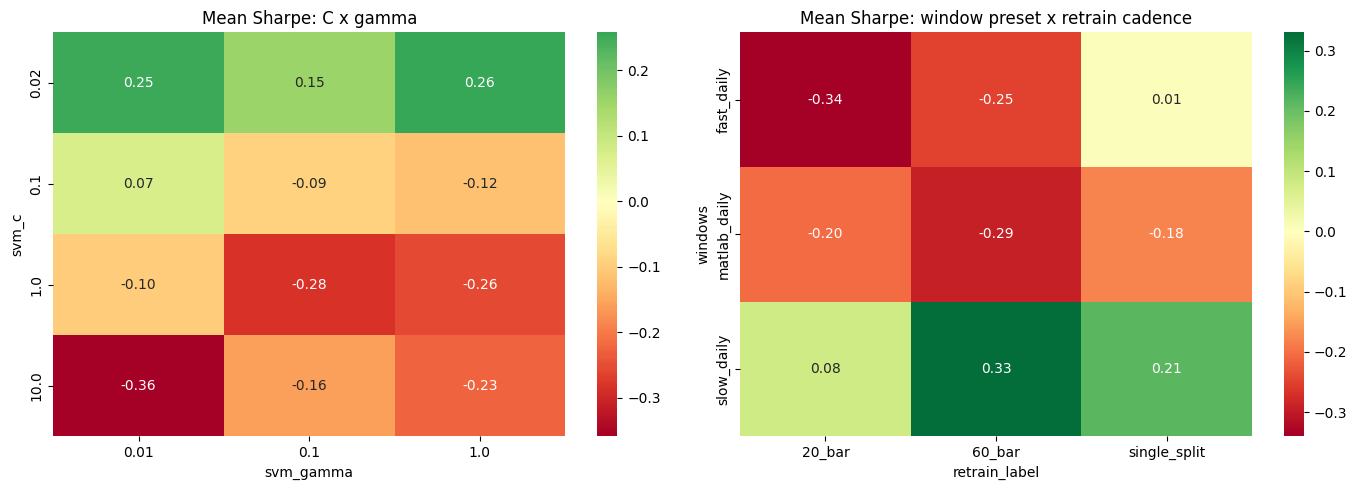

In [102]:

# -- Heatmaps -----------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

pivot_c_gamma = grid_df.pivot_table(
    values='sharpe',
    index='svm_c',
    columns='svm_gamma',
    aggfunc='mean',
)
sns.heatmap(pivot_c_gamma, annot=True, fmt='.2f', cmap='RdYlGn', center=0, ax=axes[0])
axes[0].set_title('Mean Sharpe: C x gamma')
axes[0].set_ylabel('svm_c')
axes[0].set_xlabel('svm_gamma')

pivot_windows_retrain = grid_df.pivot_table(
    values='sharpe',
    index='windows',
    columns='retrain_label',
    aggfunc='mean',
)
sns.heatmap(pivot_windows_retrain, annot=True, fmt='.2f', cmap='RdYlGn', center=0, ax=axes[1])
axes[1].set_title('Mean Sharpe: window preset x retrain cadence')
axes[1].set_ylabel('windows')
axes[1].set_xlabel('retrain_label')

plt.tight_layout()
plt.show()


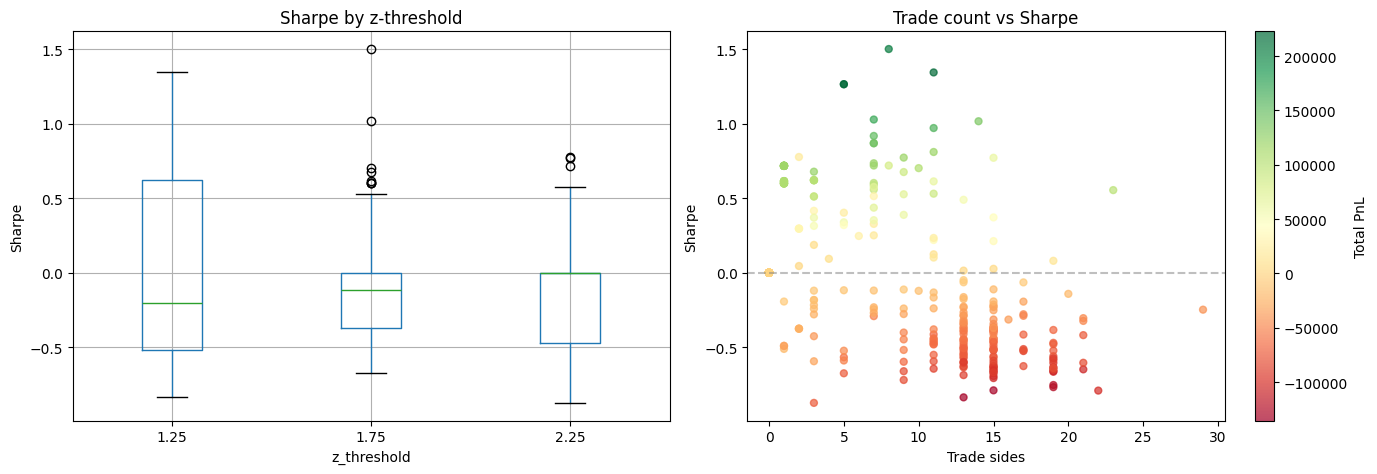

In [103]:

# -- Threshold / trade-frequency views ----------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

grid_df.boxplot(column='sharpe', by='z_threshold', ax=axes[0])
axes[0].set_title('Sharpe by z-threshold')
axes[0].set_xlabel('z_threshold')
axes[0].set_ylabel('Sharpe')

scatter = axes[1].scatter(
    grid_df['n_trades'],
    grid_df['sharpe'],
    c=grid_df['total_pnl'],
    cmap='RdYlGn',
    alpha=0.7,
    s=25,
)
fig.colorbar(scatter, ax=axes[1], label='Total PnL')
axes[1].axhline(0.0, color='gray', linestyle='--', alpha=0.5)
axes[1].set_title('Trade count vs Sharpe')
axes[1].set_xlabel('Trade sides')
axes[1].set_ylabel('Sharpe')

plt.suptitle('')
plt.tight_layout()
plt.show()


Best parameters:
  windows: slow_daily
  svm_c: 10.0
  svm_gamma: 0.1
  z_threshold: 1.75
  retrain_label: 60_bar
  Sharpe: 1.50
  Total PnL: $206,824
  Max Drawdown: $-49,890
  Trades: 8
  Win Rate: 55.4%
  Exposure Bars: 80


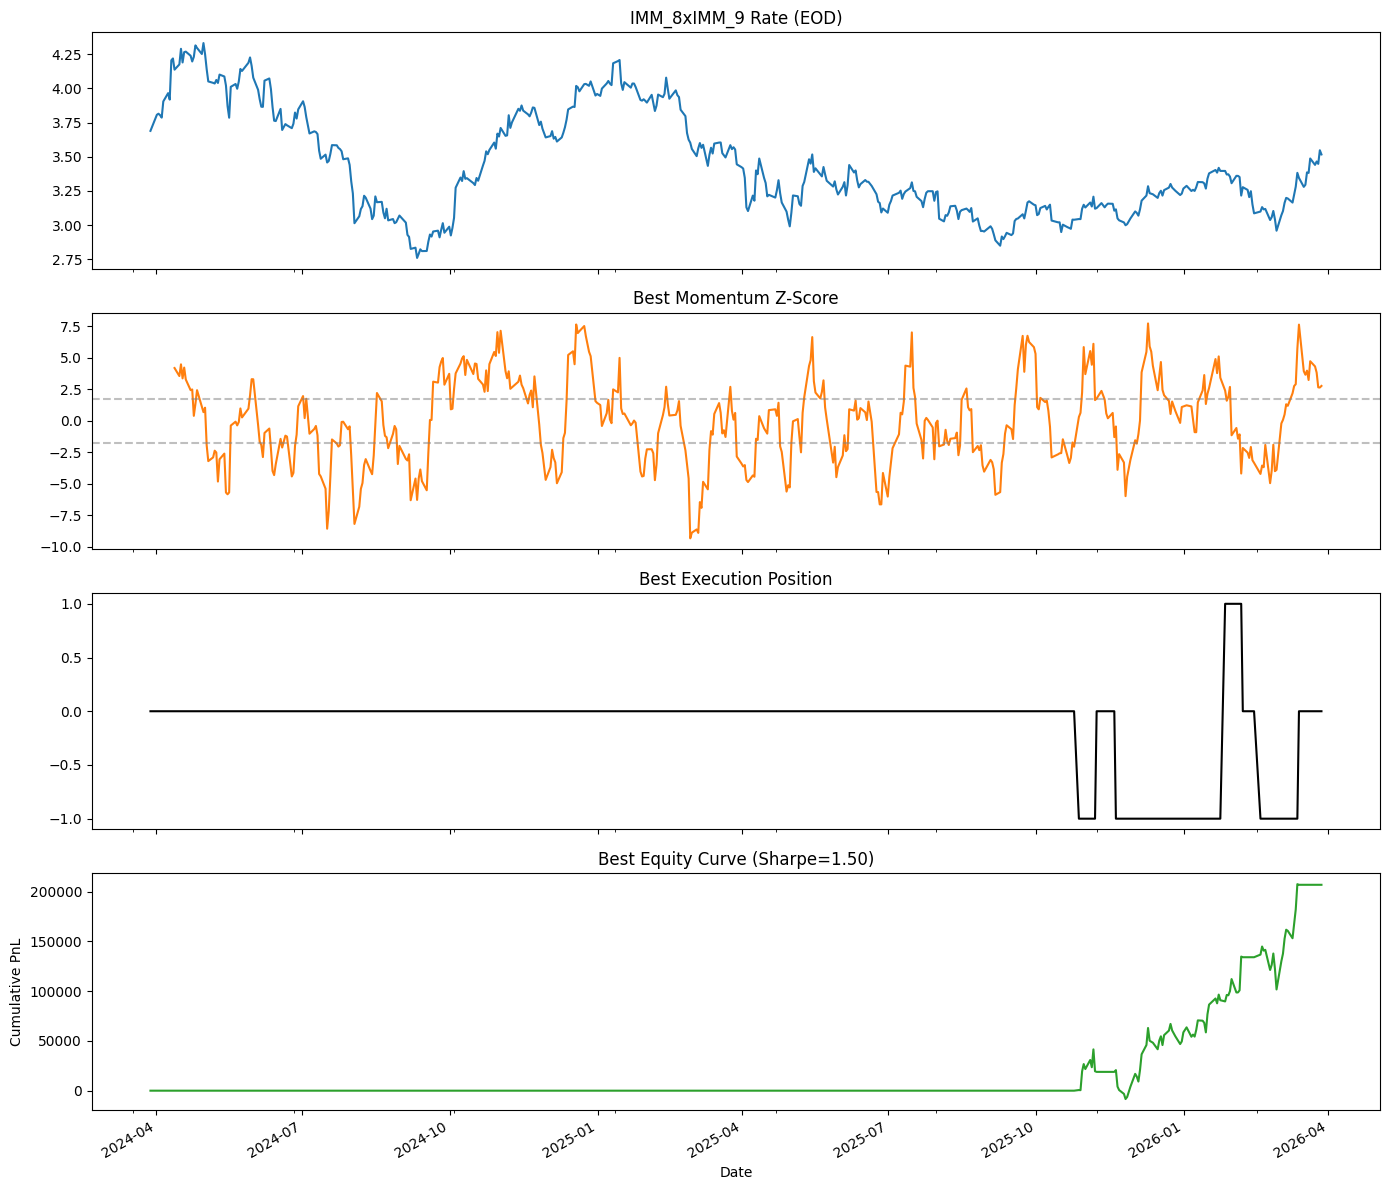

In [104]:

# -- Run the best combo and plot its equity curve -----------------------
best = grid_df.dropna(subset=['sharpe']).sort_values('sharpe', ascending=False).iloc[0]

print('Best parameters:')
for col in ['windows', 'svm_c', 'svm_gamma', 'z_threshold', 'retrain_label']:
    print(f'  {col}: {best[col]}')
print(f'  Sharpe: {best["sharpe"]:.2f}')
print(f'  Total PnL: ${best["total_pnl"]:,.0f}')
print(f'  Max Drawdown: ${best["max_drawdown"]:,.0f}')
print(f'  Trades: {best["n_trades"]:.0f}')
print(f'  Win Rate: {best["win_rate"]:.1%}')
print(f'  Exposure Bars: {best["exposure_bars"]:.0f}')

best_short, best_long = WINDOW_PRESETS[best['windows']]
best_retrain = RETRAIN_PRESETS[best['retrain_label']]

best_sig = pca_svm_momentum_signal(
    rate_series,
    ewma_short_spans=best_short,
    ewma_long_spans=best_long,
    n_components=2,
    svm_c=best['svm_c'],
    svm_gamma=best['svm_gamma'],
    label_window=10,
    z_threshold=best['z_threshold'],
    train_fraction=0.7,
    retrain_every=best_retrain,
)
best_metrics = vectorized_metrics(
    best_sig,
    rate_series,
    trade_bpv=trade_bpv,
    cost_bps=transaction_cost_bps,
    trade_direction=trade_direction,
)

fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)
rate_series.plot(ax=axes[0], title=f'{tenor} Rate (EOD)')
best_sig.indicator_frame['momentum_zscore'].dropna().plot(ax=axes[1], title='Best Momentum Z-Score', color='tab:orange')
axes[1].axhline(best['z_threshold'], color='gray', linestyle='--', alpha=0.5)
axes[1].axhline(-best['z_threshold'], color='gray', linestyle='--', alpha=0.5)
best_sig.execution_position.fillna(0.0).mul(trade_direction).plot(ax=axes[2], title='Best Execution Position', color='black')
best_metrics['cumulative'].plot(ax=axes[3], title=f'Best Equity Curve (Sharpe={best["sharpe"]:.2f})', color='tab:green')
axes[3].set_ylabel('Cumulative PnL')
plt.tight_layout()
plt.show()


In [105]:

# -- Query-driven backtest for the best combo ---------------------------
def trade_query_factory(target_position, now, info):
    _ = now, info
    return IRSwapQuery(
        curve='USD-SOFR-1D-Q12STIRT',
        tenor=tenor,
        value=IRSwapValue.NPV,
        structure_kwargs={'bpv': trade_direction * trade_bpv * float(target_position)},
        tags=('eod_pca_svm_momentum_grid_search',),
    )


query_backtest = run_technical_indicator_query_backtest(
    best_sig,
    trade_query_factory=trade_query_factory,
    mdp=curve_mdp,
    strategy_name='eod_pca_svm_momentum_grid_search',
    ignore_cache_miss=False,
    show_progress=True,
)

query_backtest.metrics


EOD_PCA_SVM_MOMENTUM_GRID_SEARCH QUERY BT: 100%|██████████| 498/498 [00:02<00:00, 225.26step/s] 


{'total_pnl': 167526.56655883556,
 'sharpe': 1.1931072812735777,
 'max_drawdown': -50494.398829653044,
 'trade_sides': 4.0}

In [110]:
from BT.query_tearsheet import QueryBacktestTearSheet
tearsheet = QueryBacktestTearSheet.from_backtest(query_backtest.backtest)
# mpl_fig = tearsheet.plot_matplotlib()
plotly_fig = tearsheet.plot_plotly(width=1400)
plotly_fig.show()

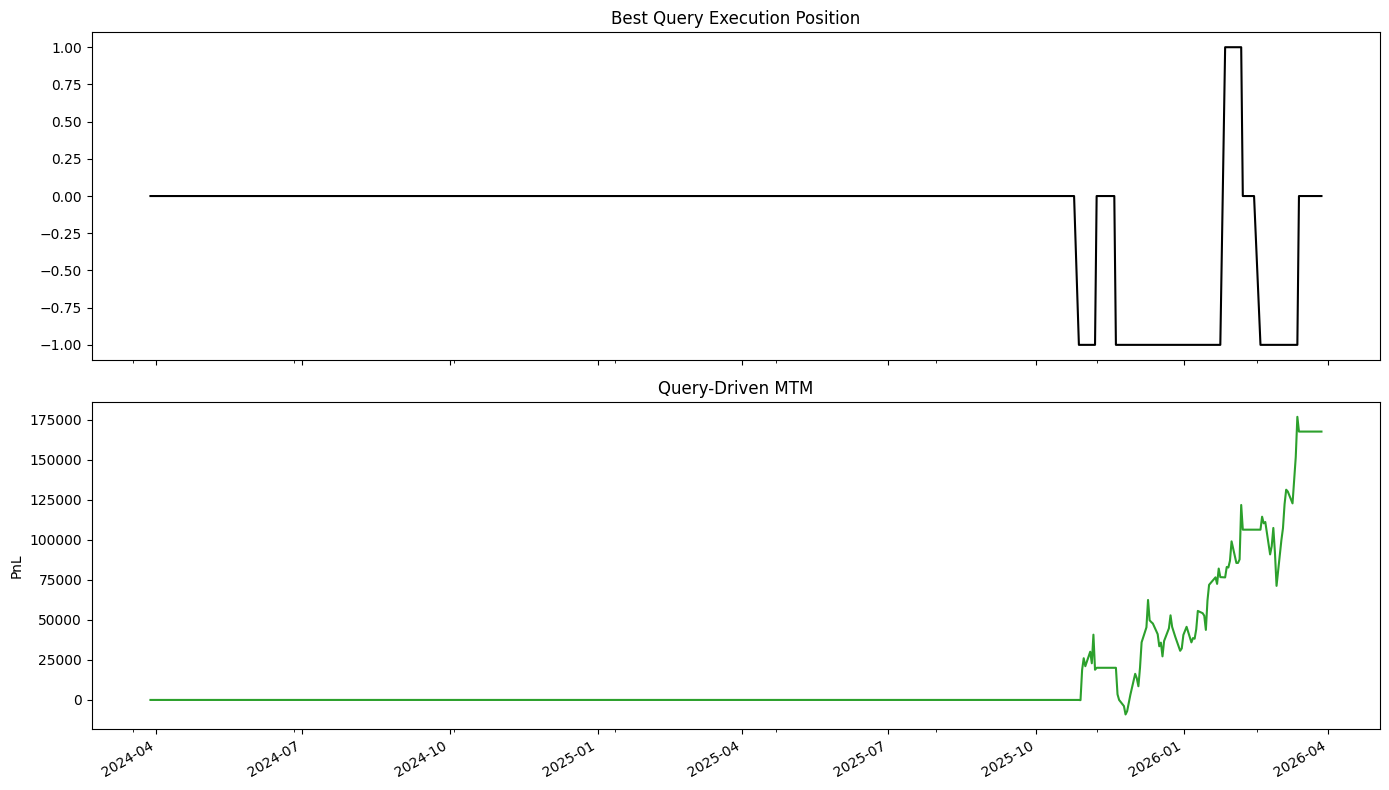

,timestamp,signal_key,raw_signal_key,position_id,signal_direction,order_type
0,2025-10-27 17:00:00-04:00,IMM_8xIMM_9,IMM_8xIMM_9,IMM_8xIMM_9|2025-10-27T17:00:00-04:00|1|leg1,-1,QueryOrder
1,2025-11-19 17:00:00-05:00,IMM_8xIMM_9,IMM_8xIMM_9,IMM_8xIMM_9|2025-11-19T17:00:00-05:00|2|leg1,-1,QueryOrder
2,2026-01-26 17:00:00-05:00,IMM_8xIMM_9,IMM_8xIMM_9,IMM_8xIMM_9|2026-01-26T17:00:00-05:00|3|leg1,1,QueryOrder
3,2026-02-17 17:00:00-05:00,IMM_8xIMM_9,IMM_8xIMM_9,IMM_8xIMM_9|2026-02-17T17:00:00-05:00|4|leg1,-1,QueryOrder


In [107]:

# -- Query-driven diagnostics -------------------------------------------
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
best_sig.execution_position.fillna(0.0).mul(trade_direction).plot(ax=axes[0], title='Best Query Execution Position', color='black')
query_backtest.mtm_history.plot(ax=axes[1], title='Query-Driven MTM', color='tab:green')
axes[1].set_ylabel('PnL')
plt.tight_layout()
plt.show()

query_backtest.order_frame.tail()


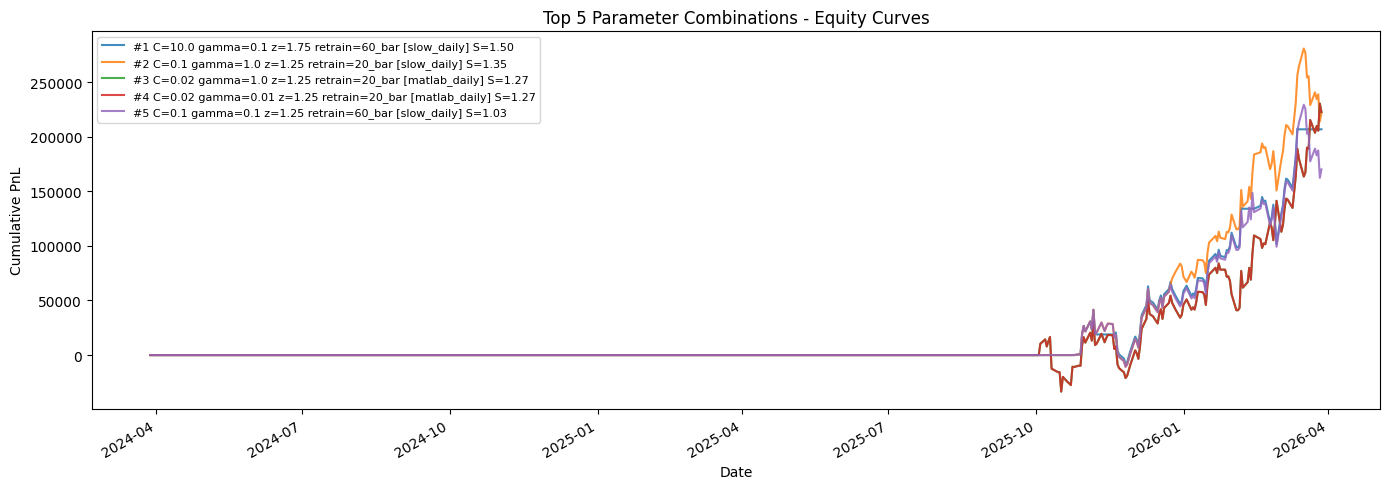

In [108]:

# -- Compare top 5 vectorized equity curves -----------------------------
top5 = grid_df.dropna(subset=['sharpe']).sort_values('sharpe', ascending=False).head(5)

fig, ax = plt.subplots(figsize=(14, 5))
for rank, (_, row) in enumerate(top5.iterrows(), start=1):
    short_spans, long_spans = WINDOW_PRESETS[row['windows']]
    retrain_every = RETRAIN_PRESETS[row['retrain_label']]
    sig = pca_svm_momentum_signal(
        rate_series,
        ewma_short_spans=short_spans,
        ewma_long_spans=long_spans,
        n_components=2,
        svm_c=row['svm_c'],
        svm_gamma=row['svm_gamma'],
        label_window=10,
        z_threshold=row['z_threshold'],
        train_fraction=0.7,
        retrain_every=retrain_every,
    )
    metrics = vectorized_metrics(
        sig,
        rate_series,
        trade_bpv=trade_bpv,
        cost_bps=transaction_cost_bps,
        trade_direction=trade_direction,
    )
    label = (
        f'#{rank} C={row["svm_c"]} gamma={row["svm_gamma"]} '
        f'z={row["z_threshold"]} retrain={row["retrain_label"]} '
        f'[{row["windows"]}] S={row["sharpe"]:.2f}'
    )
    metrics['cumulative'].plot(ax=ax, label=label, alpha=0.85)

ax.set_title('Top 5 Parameter Combinations - Equity Curves')
ax.set_ylabel('Cumulative PnL')
ax.legend(fontsize=8, loc='best')
plt.tight_layout()
plt.show()


In [109]:

# -- Export grid results ------------------------------------------------
grid_df.to_csv('eod_pca_svm_momentum_grid_results.csv', index=False)
print(f'Saved {len(grid_df)} rows to eod_pca_svm_momentum_grid_results.csv')


Saved 324 rows to eod_pca_svm_momentum_grid_results.csv
